In [11]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

In [2]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

In [3]:
mlps_models = [mlps_dic[mode_label]['model'] for mode_label in mode_labels]

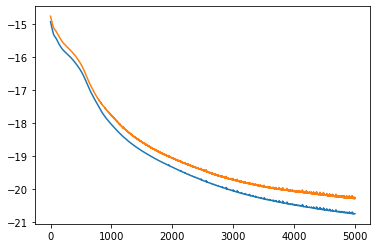

In [4]:
plt.plot(flows_dic[0]['losses'][0])
plt.plot(flows_dic[0]['losses'][1])

In [5]:
weights = torch.tensor([0.5, 0.5])
mixture = Mixture(get_models(flows_dic), weights)

In [6]:
mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']
coord_mapping = Coordinates_mapping()

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 12],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 13])
    x = join_data(x, logdetjac, energies, zmat[:, 14])
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)

In [7]:
x_u_is_init = xs
# x_u_is_init[:, 14] 
# x_u_is_init.shape
mcmc_run = run_metropolis(mixture, init=x_u_is_init, n_chains=x_u_is_init.shape[0], n_steps=5, mixture=True, mlp_models=mlps_models, energy_type='mlp', with_tqdm=True)

acc: 0.31: 100%|██████████| 5/5 [00:38<00:00,  7.69s/it]


In [12]:
mcmc_run.keys()

dict_keys(['xs', 'us', 'accs', 'isomers'])

In [9]:
from flonacomldft.free_energy_computations import compute_TFP_logratio, compute_deepBAR_logratio

In [13]:
target_log_probs = mlps_models
n_prop = 1000
mix_prop = get_models(flows_dic)

log_ratio_TFPs = []
log_err_TFPs = []
for trial in range(10):
    log_ratio_TFP, log_err_TFP = compute_TFP_logratio(n_prop, target_log_probs, mix_prop)

    log_ratio_TFPs.append(log_ratio_TFP)
    log_err_TFPs.append(log_err_TFP)

log_ratio_TFPs = np.array(log_ratio_TFPs)
log_err_TFPs = np.array(log_err_TFPs)

print(
    'log_ratio_TFPs: {:.3e} +/- {:.3e}'.format(log_ratio_TFPs.mean(), log_ratio_TFPs.std()),
    'log_err_TFPs: {:.3e} +/- {:.3e}'.format(log_err_TFPs.mean(), log_err_TFPs.std())
)

TypeError: 'list' object is not callable

In [35]:
xs = mcmc_run['xs'].reshape(-1, 12)
isomers = mcmc_run['isomers'].reshape(-1)

log_ratio_deepBARs = []
log_err_deepBARs = []

for trial in range(10):
    log_ratio_deepBAR, log_err_deepBAR = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

    log_ratio_deepBARs.append(log_ratio_deepBAR)
    log_err_deepBARs.append(log_err_deepBAR)

log_ratio_deepBARs = np.array(log_ratio_deepBARs)
log_err_deepBARs = np.array(log_err_deepBARs)

print(
    'log_ratio_deepBARs: {:.3e} +/- {:.3e}'.format(log_ratio_deepBARs.mean(), log_ratio_deepBARs.std()),
    'log_err_deepBARs: {:.3e} +/- {:.3e}'.format(log_err_deepBARs.mean(), log_err_deepBARs.std())
)

/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:164: UserWarning: Error estimation misses ESS estimation
  warnings.warn("Error estimation misses ESS estimation")
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -2.9138174895138036e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.35315085919774e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 8.129540418622128e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 4.88546863408601e-07 reached.
  warnings

log_ratio_deepBARs: -6.458e-01 +/- 1.692e+00 log_err_deepBARs: 1.075e+00 +/- 3.311e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 7.618941566533977e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -1.317191831162745e-07 reached.
  warnings.warn(msg, RuntimeWarning)


In [43]:
xs = torch.cat((xs_datasets[0][-10:, :12],xs_datasets[1][-10:, :12]))
isomers = torch.cat((xs_datasets[0][-10:, 14],xs_datasets[1][-10:, 14]))

# log_ratio_deepBARs = []
# log_err_deepBARs = []

# for trial in range(10):
#     log_ratio_deepBAR, log_err_deepBAR = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

#     log_ratio_deepBARs.append(log_ratio_deepBAR)
#     log_err_deepBARs.append(log_err_deepBAR)

# log_ratio_deepBARs = np.array(log_ratio_deepBARs)
# log_err_deepBARs = np.array(log_err_deepBARs)

# print(
#     'log_ratio_deepBARs: {:.3e} +/- {:.3e}'.format(log_ratio_deepBARs.mean(), log_ratio_deepBARs.std()),
#     'log_err_deepBARs: {:.3e} +/- {:.3e}'.format(log_err_deepBARs.mean(), log_err_deepBARs.std())
# )

In [44]:
isomers

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.])